In [1]:
import pandas as pd
import numpy as np


In [8]:
df = pd.read_csv(
    "zomato.csv",
    engine="python",
    on_bad_lines="skip"
)

df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [9]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30314 entries, 0 to 30313
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          30314 non-null  str  
 1   address                      30314 non-null  str  
 2   name                         30314 non-null  str  
 3   online_order                 30314 non-null  str  
 4   book_table                   30314 non-null  str  
 5   rate                         25805 non-null  str  
 6   votes                        30314 non-null  int64
 7   phone                        29690 non-null  str  
 8   location                     30305 non-null  str  
 9   rest_type                    30176 non-null  str  
 10  dish_liked                   13571 non-null  str  
 11  cuisines                     30290 non-null  str  
 12  approx_cost(for two people)  30177 non-null  str  
 13  reviews_list                 30314 non-null  str  
 14  m

In [13]:
df.isna().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            4509
votes                              0
phone                            624
location                           9
rest_type                        138
dish_liked                     16743
cuisines                          24
approx_cost(for two people)      137
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [19]:
 df.drop(['url','address','phone','menu_item','dish_liked'], axis=1, inplace=True)


In [21]:
df.shape

(30314, 12)

In [23]:
df.rename(columns={
    "name":"restaurent",
    "rate":"rating",
    "cuisines":"food_type",
    "listed_in(type)":"type",
    "listed_in(city)":"city",
    "approx_cost(for two people)":"cost"
}, inplace=True)

In [24]:
df.head()

,restaurent,online_order,book_table,rating,votes,location,rest_type,food_type,cost,reviews_list,type,city
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",Buffet,Banashankari


In [25]:
df.isna().sum().sum()

np.int64(4817)

In [26]:
df.dropna(inplace=True)

In [27]:
df.shape

(25604, 12)

In [29]:
df.groupby("restaurent").count()

,online_order,book_table,rating,votes,location,rest_type,food_type,cost,reviews_list,type,city
restaurent,,,,,,,,,,,
#FeelTheROLL,1,1,1,1,1,1,1,1,1,1,1
#L-81 Cafe,6,6,6,6,6,6,6,6,6,6,6
#refuel,3,3,3,3,3,3,3,3,3,3,3
1000 B.C,4,4,4,4,4,4,4,4,4,4,4
100ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ°C,3,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...
i-Bar - The Park Bangalore,6,6,6,6,6,6,6,6,6,6,6
iFruit Live Ice Creams,1,1,1,1,1,1,1,1,1,1,1
iSpice Resto Cafe,3,3,3,3,3,3,3,3,3,3,3


In [31]:
df['restaurent'] = df['restaurent'].str.replace('[Ãx][^A-Za-z]+','',regex=True)

In [33]:
df.groupby("restaurent").count()

,online_order,book_table,rating,votes,location,rest_type,food_type,cost,reviews_list,type,city
restaurent,,,,,,,,,,,
#FeelTheROLL,1,1,1,1,1,1,1,1,1,1,1
#L-81 Cafe,6,6,6,6,6,6,6,6,6,6,6
#refuel,3,3,3,3,3,3,3,3,3,3,3
1000 B.C,4,4,4,4,4,4,4,4,4,4,4
100C,3,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...
i-Bar - The Park Bangalore,6,6,6,6,6,6,6,6,6,6,6
iFruit Live Ice Creams,1,1,1,1,1,1,1,1,1,1,1
iSpice Resto Cafe,3,3,3,3,3,3,3,3,3,3,3


In [34]:
df.rating.unique()

<StringArray>
[ '4.1/5',  '3.8/5',  '3.7/5',  '3.6/5',  '4.6/5',  '4.0/5',  '4.2/5',
  '3.9/5',  '3.1/5',  '3.0/5',  '3.2/5',  '3.3/5',  '2.8/5',  '4.4/5',
  '4.3/5',    'NEW',  '2.9/5',  '3.5/5',  '2.6/5', '3.8 /5',  '3.4/5',
  '4.5/5',  '2.5/5',  '2.7/5',  '4.7/5',  '2.4/5',  '2.2/5',  '2.3/5',
 '3.4 /5',      '-', '3.6 /5',  '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
 '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5', '3.5 /5',
 '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5', '4.3 /5', '4.4 /5',
  '4.9/5',  '2.1/5',  '2.0/5',  '1.8/5', '4.6 /5', '4.9 /5', '3.0 /5',
 '4.8 /5', '2.3 /5', '2.4 /5', '4.7 /5']
Length: 60, dtype: str

In [47]:
replace = lambda x:str(x).replace('/5',"")
l = []
for val in map(replace,df['rating']):
    if val != 'NEW' and val != '-':
        var = float(val)
    l.append(var)
df['rating'] = l

In [48]:
df.rating.unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2, 2.3,
       4.8, 4.9, 2.1, 2. , 1.8])

In [50]:
df['votes'].isnull().value_counts()

votes
False    25604
Name: count, dtype: int64

In [51]:
df.location.unique()

<StringArray>
[                 'Banashankari',                  'Basavanagudi',
                   'Mysore Road',                     'Jayanagar',
            'Kumaraswamy Layout',          'Rajarajeshwari Nagar',
                   'Vijay Nagar',                   'Uttarahalli',
                      'JP Nagar',               'South Bangalore',
                   'City Market',             'Bannerghatta Road',
                           'BTM',               'Kanakapura Road',
                  'Bommanahalli',                'CV Raman Nagar',
               'Electronic City',                 'Wilson Garden',
                  'Shanti Nagar',         'Koramangala 5th Block',
                 'Richmond Road',                           'HSR',
                  'Marathahalli',         'Koramangala 7th Block',
                     'Bellandur',                 'Sarjapur Road',
                    'Whitefield',                'East Bangalore',
              'Old Airport Road',               

In [52]:
df['rest_type'].unique()

<StringArray>
[                'Casual Dining',           'Cafe, Casual Dining',
                   'Quick Bites',           'Casual Dining, Cafe',
                          'Cafe',             'Quick Bites, Cafe',
             'Cafe, Quick Bites',                      'Delivery',
                          'Mess',                'Dessert Parlor',
        'Bakery, Dessert Parlor',                           'Pub',
                        'Bakery',            'Takeaway, Delivery',
                   'Fine Dining',                 'Beverage Shop',
                    'Sweet Shop',                           'Bar',
    'Dessert Parlor, Sweet Shop',           'Bakery, Quick Bites',
       'Sweet Shop, Quick Bites',                         'Kiosk',
                    'Food Truck',   'Quick Bites, Dessert Parlor',
    'Beverage Shop, Quick Bites', 'Beverage Shop, Dessert Parlor',
                      'Takeaway',            'Pub, Casual Dining',
            'Casual Dining, Bar', 'Dessert Parlo

In [54]:
df.cost.unique()

<StringArray>
[  '800',   '300',   '600',   '700',   '550',   '500',   '450',   '650',
   '400',   '900',   '200',   '750',   '150',   '850',   '100', '1,200',
   '350',   '250',   '950', '1,000', '1,500', '1,300',   '199',    '80',
 '1,100',   '160', '1,600',   '230',   '130', '1,700', '1,400', '1,350',
 '2,200', '2,000', '1,800', '1,900',   '180',   '330', '2,500', '2,100',
 '3,000', '2,800', '3,400',    '50',    '40', '1,250', '3,500', '4,000',
 '2,400', '2,600', '1,450',    '70', '3,200',   '560',   '240',   '360',
 '6,000', '1,050', '2,300']
Length: 59, dtype: str

In [55]:
df['cost'] = df['cost'].apply(lambda x:x.replace(",","")).astype(int)

In [56]:
df.cost.unique()

array([ 800,  300,  600,  700,  550,  500,  450,  650,  400,  900,  200,
        750,  150,  850,  100, 1200,  350,  250,  950, 1000, 1500, 1300,
        199,   80, 1100,  160, 1600,  230,  130, 1700, 1400, 1350, 2200,
       2000, 1800, 1900,  180,  330, 2500, 2100, 3000, 2800, 3400,   50,
         40, 1250, 3500, 4000, 2400, 2600, 1450,   70, 3200,  560,  240,
        360, 6000, 1050, 2300])

In [57]:
df.type.unique()

<StringArray>
[            'Buffet',              'Cafes',           'Delivery',
           'Desserts',           'Dine-out', 'Drinks & nightlife',
      'Pubs and bars']
Length: 7, dtype: str

In [58]:
df.city.unique()

<StringArray>
[         'Banashankari',     'Bannerghatta Road',          'Basavanagudi',
             'Bellandur',          'Brigade Road',           'Brookefield',
                   'BTM',         'Church Street',       'Electronic City',
           'Frazer Town',                   'HSR',           'Indiranagar',
             'Jayanagar',              'JP Nagar',          'Kalyan Nagar',
          'Kammanahalli', 'Koramangala 4th Block', 'Koramangala 5th Block']
Length: 18, dtype: str

In [59]:
df.drop(['reviews_list'],axis=1,inplace=True)

In [60]:
df.head()

,restaurent,online_order,book_table,rating,votes,location,rest_type,food_type,cost,type,city
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


In [65]:
df.duplicated().value_counts()

False    25544
True        60
Name: count, dtype: int64

In [67]:
df.drop_duplicates(keep="last", inplace=True)

In [68]:
df.duplicated().value_counts()

False    25544
Name: count, dtype: int64

In [69]:
df.reset_index()

,index,restaurent,online_order,book_table,rating,votes,location,rest_type,food_type,cost,type,city
0,0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...
25539,30308,Punjabi Unplugged,Yes,No,4.1,0,Koramangala 1st Block,Quick Bites,North Indian,500,Delivery,Koramangala 5th Block
25540,30309,The Biriyani Factory,Yes,No,3.1,30,BTM,Quick Bites,"North Indian, Biryani",500,Delivery,Koramangala 5th Block
25541,30310,Berry'd Alive,Yes,No,4.3,1902,Koramangala 5th Block,Dessert Parlor,Desserts,400,Delivery,Koramangala 5th Block
25542,30312,Guns N Roses,Yes,No,3.6,23,Ejipura,Quick Bites,"Fast Food, Biryani",300,Delivery,Koramangala 5th Block


In [70]:
df.info()

<class 'pandas.DataFrame'>
Index: 25544 entries, 0 to 30313
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   restaurent    25544 non-null  str    
 1   online_order  25544 non-null  str    
 2   book_table    25544 non-null  str    
 3   rating        25544 non-null  float64
 4   votes         25544 non-null  int64  
 5   location      25544 non-null  str    
 6   rest_type     25544 non-null  str    
 7   food_type     25544 non-null  str    
 8   cost          25544 non-null  int64  
 9   type          25544 non-null  str    
 10  city          25544 non-null  str    
dtypes: float64(1), int64(2), str(8)
memory usage: 2.3 MB


In [73]:
df.to_csv(r"C:\Users\Swaranjali Desai\Downloads\Zomato EDA\zomato_clean.csv")

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'seaborn'

In [2]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 2.1 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.5 MB 1.9 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.5 MB 2.0 MB/s eta 0:00:05
   ------ --------------------------------- 1.6/9.5 MB 1.7 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.5 MB 1.7 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.5 MB 1.7 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.5 MB 1.7 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.5 MB 1.6 MB/s eta 0:00:05
   --

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
df1 = pd.read_csv("zomato_clean.csv", index_col=0)

In [12]:

df1.shape

(25544, 11)

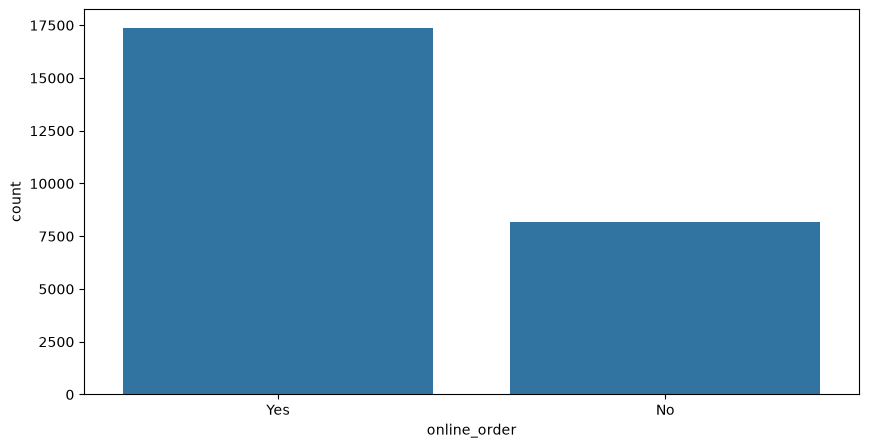

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(x='online_order', data=df1)
plt.show()

1. Above Bar Chart shows count of Restaurents that delivery online 

2. Finding best Location:

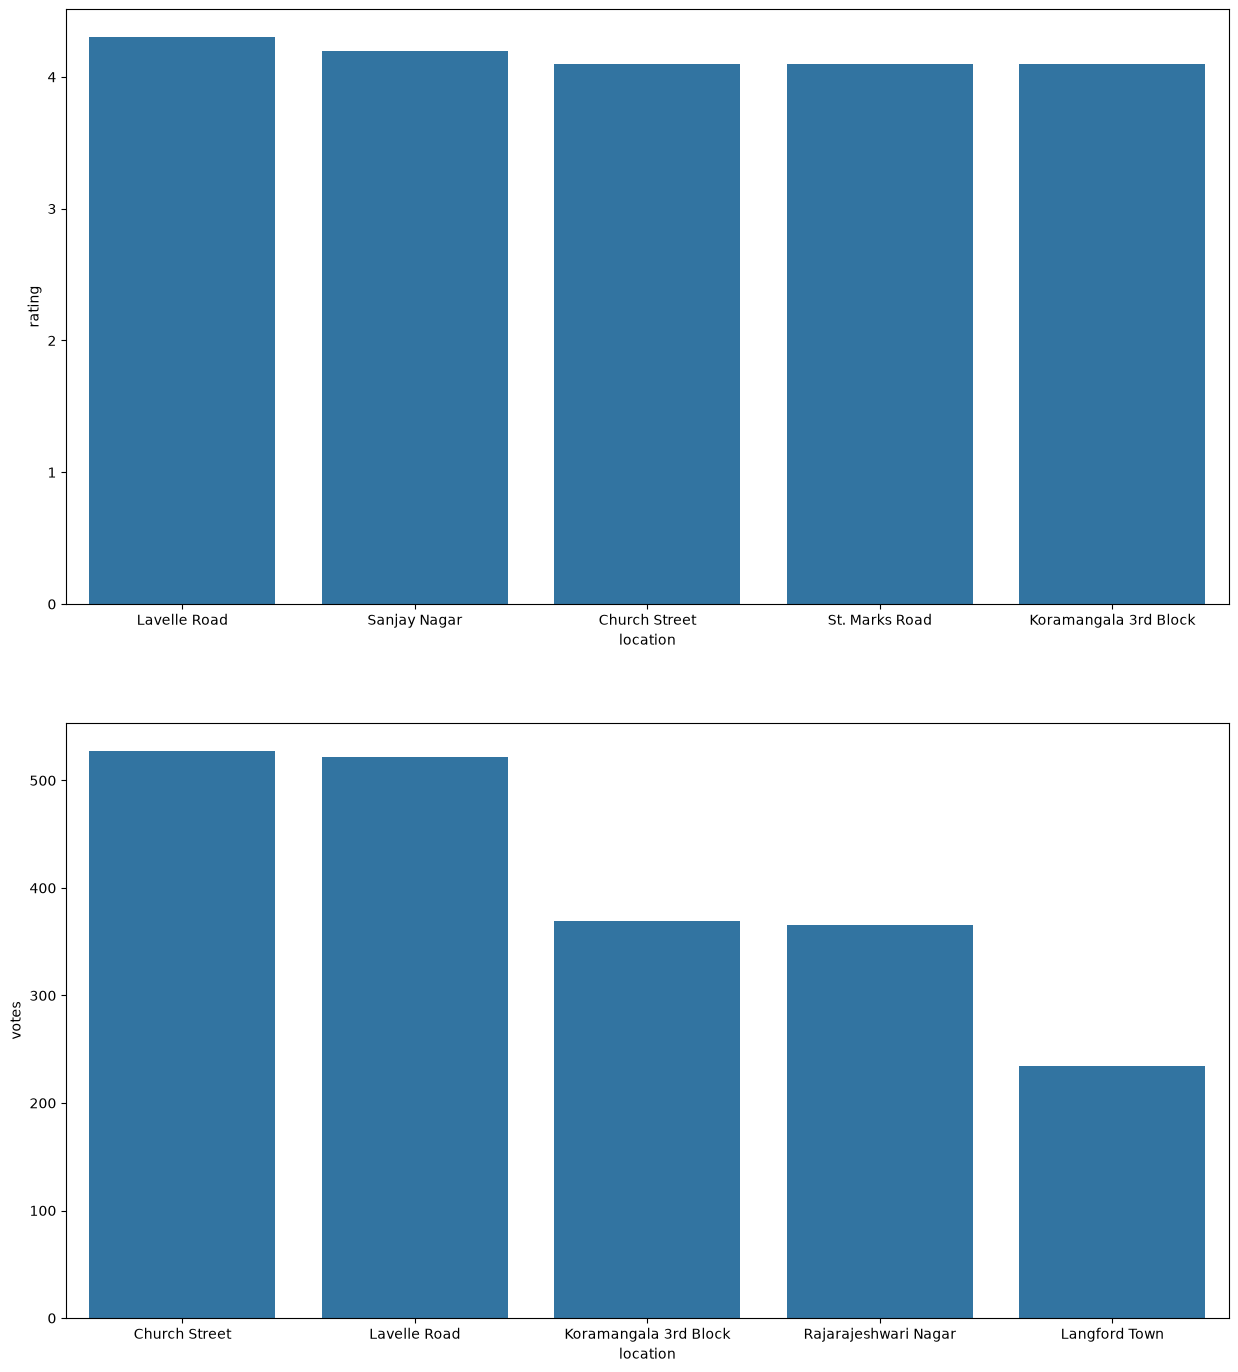

In [22]:
plt.figure(figsize=(15,17))
ax = plt.subplot(2,1,1)

loc_rating = df1.groupby('location').agg({'rating':'median'})
rating_sorted_loc = loc_rating.sort_values('rating', ascending=False).head(5).reset_index()
sns.barplot(y='rating', x='location', data=rating_sorted_loc)

ax = plt.subplot(2,1,2)

loc_rating = df1.groupby('location').agg({'votes':'median'})
votes_sorted_loc = loc_rating.sort_values('votes', ascending=False).head(5).reset_index()
sns.barplot(y='votes', x='location', data=votes_sorted_loc)

plt.show()

3. Find Types of Restaurent and their counts

(np.int64(84), <Axes: xlabel='restaurent', ylabel='rest_type'>)

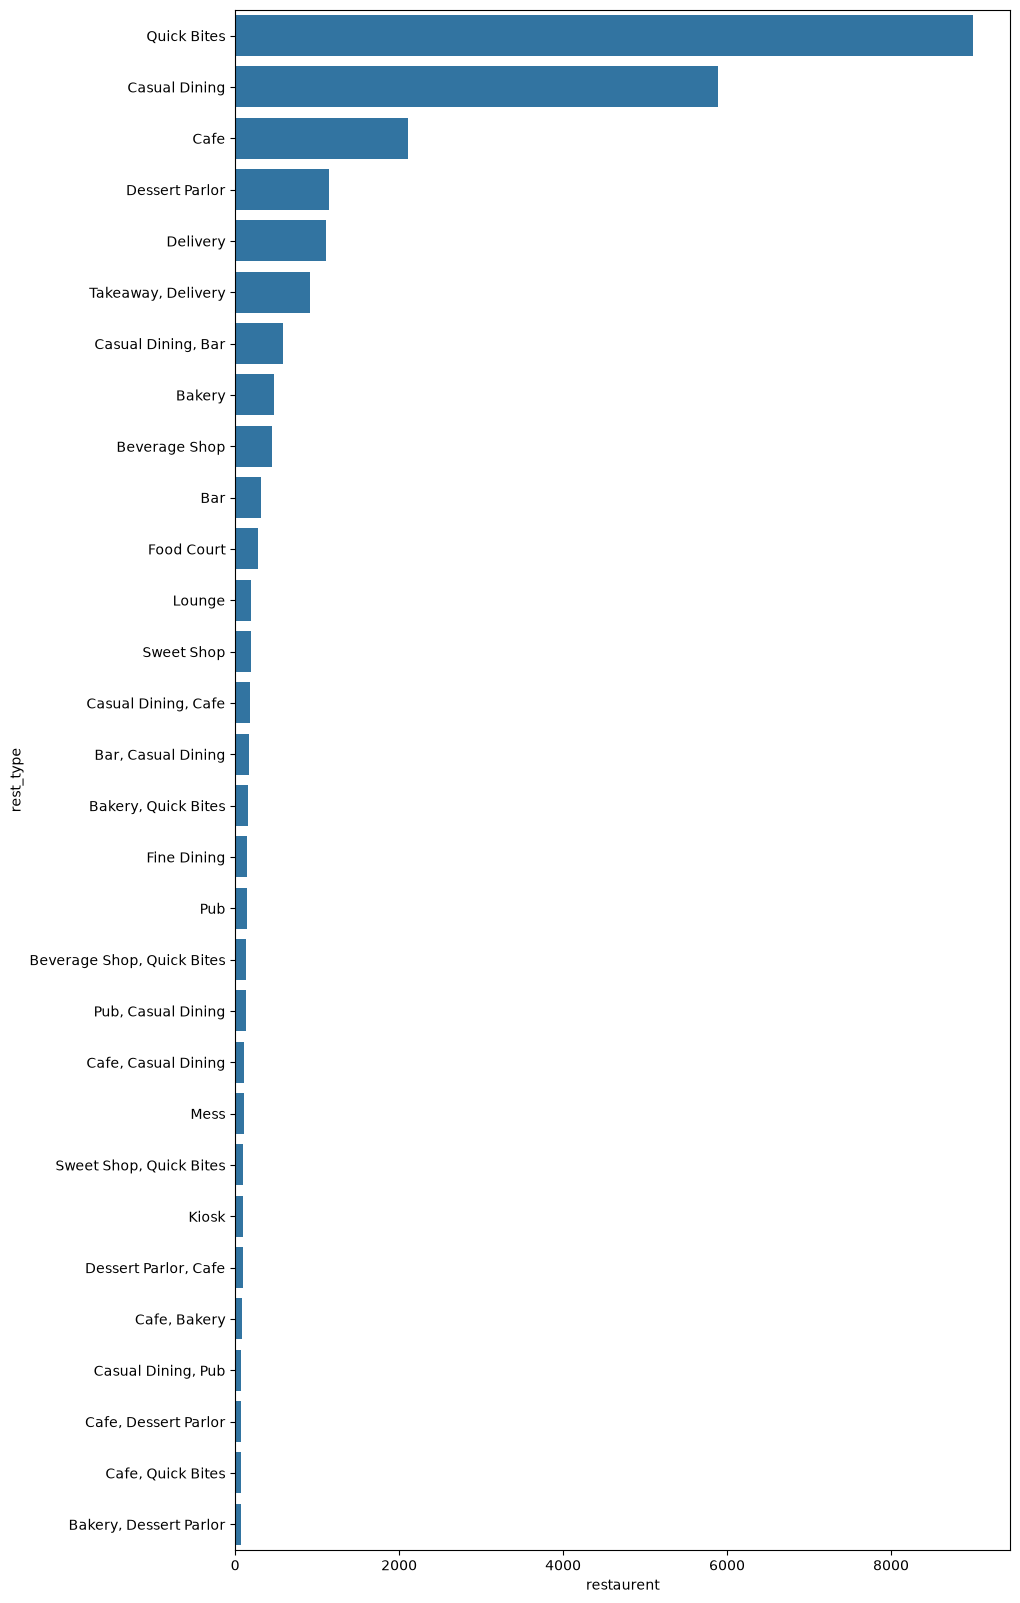

In [32]:
plt.figure(figsize=(10,20))
rest_types = df1.groupby('rest_type')['restaurent'].count().reset_index()
sorted_rest_types = rest_types.sort_values('restaurent',ascending=False).head(30)
#print(sorted_rest_types)

rest_types.rest_type.count(), sns.barplot(x='restaurent',y='rest_type',data = sorted_rest_types, orient='h')

4. Find cost of Restaurents

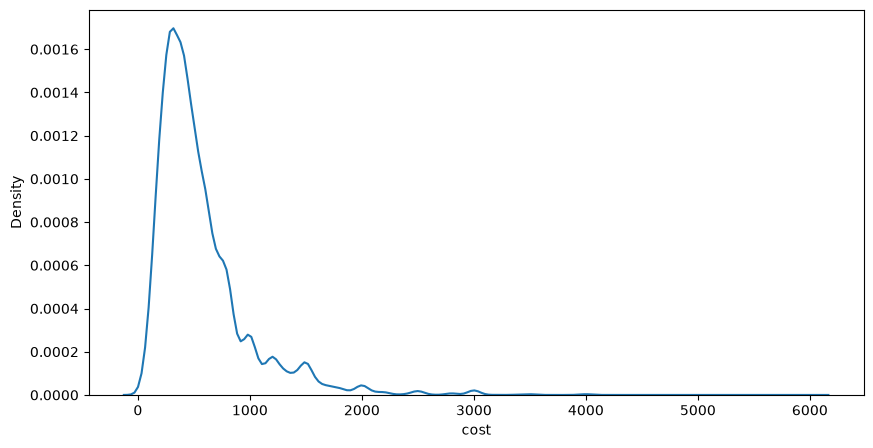

In [34]:
plt.figure(figsize=(10,5))
sns.kdeplot(x='cost', data=df1)
plt.show()

5. Table of restaurents having table booking facilities

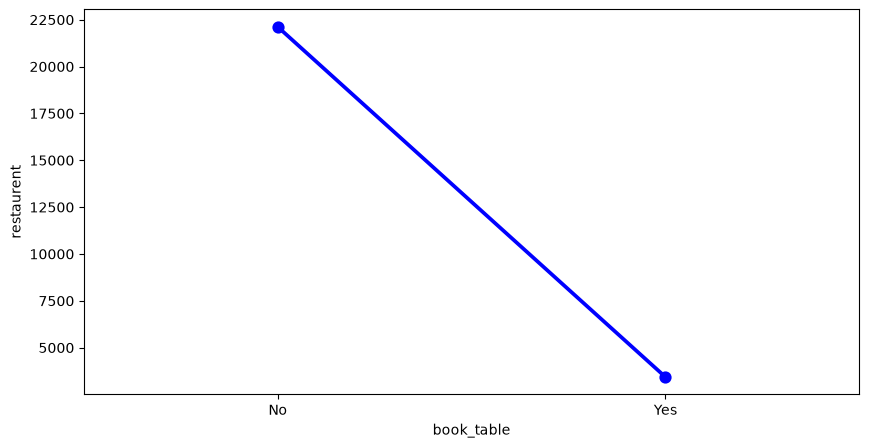

In [37]:
plt.figure(figsize=(10,5))
table_booking = df1.groupby('book_table')['restaurent'].count().reset_index()

sns.pointplot(x='book_table', y='restaurent', color='b', data=table_booking)
plt.show()

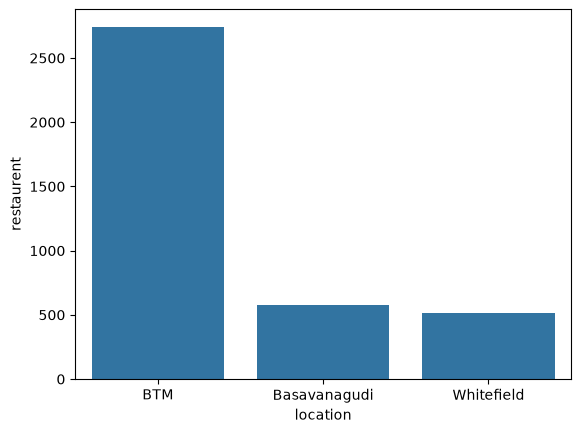

In [44]:
df = pd.DataFrame(df1.groupby('location')['restaurent'].count()).reset_index()
criteria=df['location'].isin(['BTM','Basavanagudi','West Bangalore','Whitefield','Yeshwantpur'])

sns.barplot(x='location',y='restaurent',data=df[criteria])
plt.show()